In [ ]:
import psycopg2

 

Connected successfully!


In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from Services.dbconnector import getconnection

print(getconnection())

<connection object at 0x000001CABE213EF0; dsn: 'user=postgres password=xxx dbname=smartretail host=localhost port=5432', closed: 0>


In [ ]:
import pandas as pd 

a = pd.read_csv ("../data/review.tsv" )
a.head()

In [ ]:
import importlib
import Services.ingestservice as ingestservice
importlib.reload(ingestservice)

from Services.ingestservice import ingestall
ingestall()
os.chdir(r"C:\Users\Siddhu\Desktop\personal\studying\Uplift\Project\SmartRetail")
print(os.getcwd()) 
 

el = ingestall()
print(el)

In [17]:
import os
os.chdir("..")  # move to SmartRetail/ root
print(os.getcwd())  # confirm

c:\Users\Siddhu\Desktop\personal


In [ ]:
import os
os.chdir("..")  # move to SmartRetail/ root
print(os.getcwd())  # confirm

"C:\Users\Siddhu\Desktop\personal\studying\Uplift\Project\SmartRetail\data\review.tsv"

c:\Users\Siddhu\Desktop


In [ ]:
import pandas as pd

cols = ["review_id", "product_id", "product_title",
        "star_rating", "review_headline", "review_body", "review_date"]

df = pd.read_csv(r"C:\Users\Siddhu\Desktop\personal\studying\Uplift\Project\SmartRetail\data\review.tsv", sep="\t", usecols=cols)
print(df.shape)
print(df.dtypes)
print(df["star_rating"].unique()[:20])

In [10]:
import os
# os.chdir("..")
import pandas as pd 
from Services.ingestservice import getengine
from sqlalchemy import text

engine = getengine()
df= pd.read_sql("select * from bronze.sales" ,engine)
print(df.head(1))
df = df[~df["Invoice"].str.lower().str.startswith("c")]

df = df[ (df["Quantity"] >0)  & (df["Price"] > 0 )]
df = df.dropna(subset=["Customer ID","Description"])

df = df.drop_duplicates()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]) 

df["Revenue"] = df["Quantity"] * df["Price"]
print(df.head())
df.shape

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  Revenue  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom     83.4  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom     81.0  
3 2009-12-01 07:45:00   2.10      13085.

(779425, 9)

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.head())

In [ ]:
df['yearmonth'] = df["InvoiceDate"].dt.to_period('M').astype(str)
df1 = df.groupby("yearmonth").agg(
            Invoicecount =  ("Invoice" , 'nunique'),
            MonthlyRevenue = ("Revenue",'sum'),
            monAvgRev = ("Revenue",'mean')

        )

print(df1.shape)
print(df1.dtypes)
print(df1.head())

In [20]:
df1.to_sql("sales", getengine(), schema="gold", if_exists="replace", index=True)

25

In [ ]:
df= pd.read_sql("select * from bronze.reviews" ,engine)

df.head(1)


In [15]:
df= pd.read_sql("select * from bronze.reviews" ,engine) 
df = df.dropna(subset=["review_body"])
df = df.drop_duplicates()
df.to_sql("reviews",engine, schema="gold", if_exists="replace", index=False)
        

303

2026-07-22 00:16:42,922 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-22 00:16:42,924 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


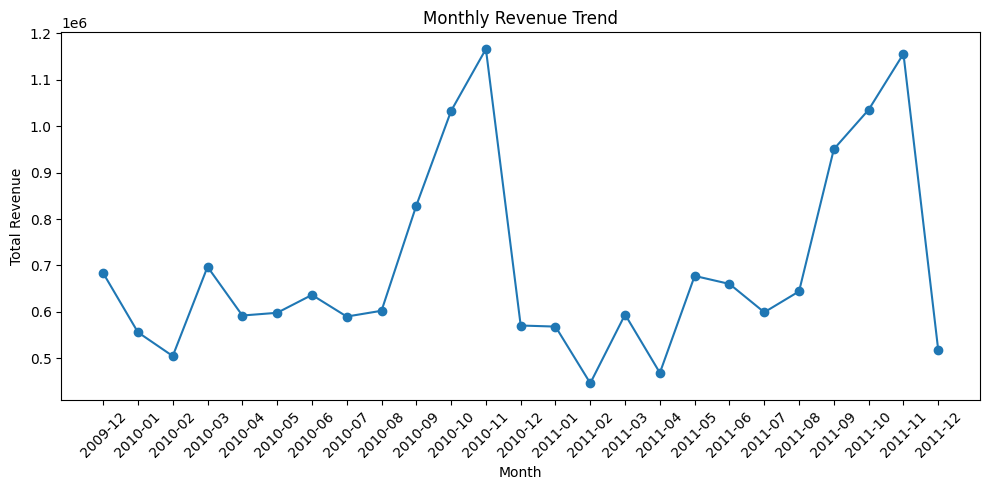

In [22]:
import pandas as pd
from Services.ingestservice import getengine
from Services.transformservice import cleansales
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_sql("select * from gold.sales" ,getengine())
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(data["yearmonth"], data["MonthlyRevenue"], marker="o")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
ax.set_title("Monthly Revenue Trend"    )
plt.xticks(rotation = 45)
plt.tight_layout()


2026-07-22 00:16:53,501 - INFO - Sales data fetched 25


KeyError: 'monthlyrevenue'

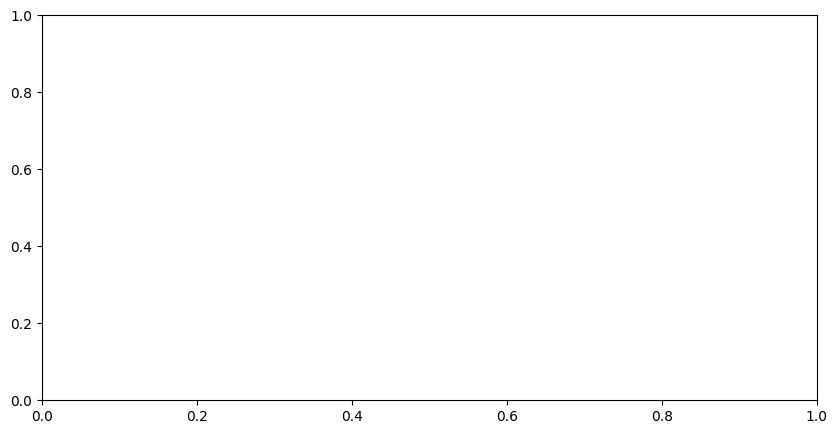

In [23]:
from Services.visualizeservice import plottopproducts, plotmonthlytrend, plotratingdist
import matplotlib.pyplot as plt

# fig1 = plottopproducts()
# plt.show()

fig2 = plotmonthlytrend()
plt.show()

fig3 = plotratingdist()
plt.show()